In [10]:
from pathlib import Path
from warnings import filterwarnings

import pandas as pd
import numpy as np
from sklearn import svm, metrics, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import auc, accuracy_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import MACCSkeys, rdFingerprintGenerator

# Silence some expected warnings
filterwarnings("ignore")
# Fix seed for reproducible results
SEED = 22


# load in data
filepath = "/home/lme/mol_mod_pr/Day_5/bioactivity_and_smiles.csv"
chembl_df = pd.read_csv(filepath,sep="\t")

print(chembl_df.shape)

# Keep only the relevant columns
chembl_df = chembl_df.rename(columns={"canonical_smiles": "smiles"})
chembl_df = chembl_df[["molecule_chembl_id","smiles", "pIC50"]]

# Label the compounds into active and inactive
pIC50_threshold = 6.5

chembl_df["active"] = np.where(chembl_df["pIC50"] >= pIC50_threshold, 1, 0)

# Count Number of active and inactive compounds
active_count = chembl_df["active"].value_counts()
print("Number of active compounds: ", active_count[1])
print("Number of inactive compounds: ", active_count[0])


(3815, 7)
Number of active compounds:  1491
Number of inactive compounds:  2324


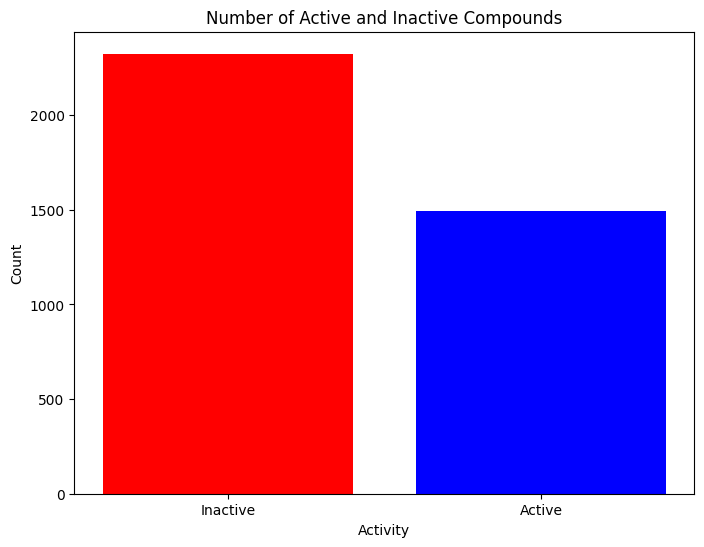

In [11]:
# Plot number of active and inactive compounds
plt.figure(figsize=(8, 6))
plt.bar(active_count.index, active_count.values, color=["red", "blue"])
plt.xticks(active_count.index, ["Inactive", "Active"])
plt.xlabel("Activity")
plt.ylabel("Count")
plt.title("Number of Active and Inactive Compounds")
plt.savefig("active_inactive_count.png")
plt.show()

In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.Chem.AtomPairs import Pairs, Torsions

from rdkit.Chem import rdFingerprintGenerator


# here write your smiles_to_fp function and add columns for calculated fingerprints to original dataframe
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.
        All methods: maccs, morgan2, morgan3, ap, tt, rdkit

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.

    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=n_bits)
    rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=n_bits)
    mfpgen3 = rdFingerprintGenerator.GetMorganGenerator(radius=3,fpSize=n_bits)
    apgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=n_bits)
    ttgen=rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=n_bits)

    if method == "maccs":
        fp = MACCSkeys.GenMACCSKeys(mol)
    elif method == "morgan2":
        fp = mfpgen.GetFingerprint(mol)
    elif method == "morgan3":
        fp = mfpgen3.GetFingerprint(mol)
    elif method == "rdkit":
        fp = rdkgen.GetFingerprint(mol)
    elif method == "ap":
        fp = apgen.GetFingerprint(mol)
    elif method == "tt":
        fp = ttgen.GetFingerprint(mol)
    else:
        raise ValueError(f"Unsupported fingerprint method: {method}")

    return np.array(fp)

# Apply the function to the dataframe
chembl_df["maccs"] = chembl_df["smiles"].apply(smiles_to_fp, method="maccs")
chembl_df["morgan2"] = chembl_df["smiles"].apply(smiles_to_fp, method="morgan2")
chembl_df["morgan3"] = chembl_df["smiles"].apply(smiles_to_fp, method="morgan3")
chembl_df["rdkit"] = chembl_df["smiles"].apply(smiles_to_fp, method="rdkit")
chembl_df["ap"] = chembl_df["smiles"].apply(smiles_to_fp, method="ap")
chembl_df["tt"] = chembl_df["smiles"].apply(smiles_to_fp, method="tt")


# Setup Model Validation

We use K-Fold Cross Validation to evaluate the model

In [13]:
from sklearn.metrics import roc_curve, auc


def plot_roc_curves_for_models(models, test_x, test_y, save_png=False, filename="roc_curves.png"):
    """
    Helper function to plot customized ROC curve.

    Parameters
    ----------
    models: dict
        Dictionary of pretrained machine learning models.
    test_x: array-like
        Molecular fingerprints for test set.
    test_y: array-like
        Associated activity labels for test set.
    save_png: bool, optional
        Save image to disk (default = False).
    filename: str, optional
        Filename to save the plot if save_png is True (default = "roc_curves.png").

    Returns
    -------
    None
    """
    plt.figure(figsize=(8, 6))
    
    for name, model in models.items():
        try:
            # Get prediction probabilities (ensure classifier has predict_proba or decision_function)
            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(test_x)[:, 1]
            elif hasattr(model, "decision_function"):
                probs = model.decision_function(test_x)
            else:
                raise AttributeError(f"Model {name} does not support probability or decision function.")
            
            # Calculate ROC curve and AUC
            fpr, tpr, _ = roc_curve(test_y, probs)
            roc_auc = auc(fpr, tpr)

            # Plot the ROC curve
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
        except Exception as e:
            print(f"Error processing model {name}: {e}")

    # Plot diagonal reference line
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

    # Add labels, title, and legend
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Models')
    plt.legend(loc="lower right")
    plt.grid(True)

    # Save the plot if requested
    if save_png:
        plt.savefig(filename)
        print(f"ROC curve saved as {filename}")

    # Show the plot
    plt.show()

In [14]:
def model_performance(ml_model, test_x, test_y, verbose=True):
    """
    Helper function to calculate model performance

    Parameters
    ----------
    ml_model: sklearn model object
        The machine learning model to train.
    test_x: list
        Molecular fingerprints for test set.
    test_y: list
        Associated activity labels for test set.
    verbose: bool
        Print performance measure (default = True)

    Returns
    -------
    tuple:
        Accuracy, sensitivity, specificity, auc on test set.
    """
    # Prediction probabilities and classes
    test_prob = ml_model.predict_proba(test_x)[:, 1]
    test_pred = ml_model.predict(test_x)

    # Accuracy
    accuracy = accuracy_score(test_y, test_pred)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(test_y, test_pred).ravel()

    # Sensitivity (Recall for positive class)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Specificity (Recall for negative class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    # AUC
    auc = roc_auc_score(test_y, test_prob)

    if verbose:
        print(f"Accuracy:     {accuracy:.2f}")
        print(f"Sensitivity:  {sens:.2f}")
        print(f"Specificity:  {spec:.2f}")
        print(f"AUC:          {auc:.2f}")

    return accuracy, sens, spec, auc

# Following helper function is used to determine the model performance

def model_training_and_validation(ml_model, name, splits, verbose=True):
    """
    Fit a machine learning model on a random train-test split of the data
    and return the performance measures.

    Parameters
    ----------
    ml_model: sklearn model object
        The machine learning model to train.
    name: str
        Name of machine learning algorithm: RF, SVM, ANN
    splits: list
        List of desciptor and label data: train_x, test_x, train_y, test_y.
    verbose: bool
        Print performance info (default = True)

    Returns
    -------
    tuple:
        Accuracy, sensitivity, specificity, auc on test set.

    """
    print(f"We're using {name} algorithm for classification task.")
    train_x, test_x, train_y, test_y = splits

    # Fit the model
    ml_model.fit(train_x, train_y)

    # Calculate model performance results
    accuracy, sens, spec, auc = model_performance(ml_model, test_x, test_y, verbose)

    return accuracy, sens, spec, auc

In [15]:
# Import necessary libraries for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (make_scorer, accuracy_score, precision_score, 
                            recall_score, f1_score, roc_auc_score, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict

def perform_kfold_cv(X, y, model, k=5, random_state=42):
    """
    Perform k-fold cross-validation for a classification model with molecular data.
    
    Parameters
    ----------
    X : list or array
        Feature vectors (molecular fingerprints)
    y : list or array
        Target labels (active/inactive compounds)
    model : sklearn estimator
        Model to evaluate (RandomForestClassifier in this case)
    k : int
        Number of folds - the article suggests 5 or 10 as a good balance
    random_state : int
        Random seed for reproducibility
        
    Returns
    -------
    dict
        Dictionary containing performance metrics for each fold and averages
    """
    # Convert lists to numpy arrays if needed
    X = np.array(X)
    y = np.array(y)
    
    # Define the k-fold cross-validator
    # Using StratifiedKFold to maintain the same class distribution in each fold
    # This is important for potentially imbalanced chemical activity datasets
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    
    # Define scoring metrics relevant for compound activity classification
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score,zero_division=0),
        'recall': make_scorer(recall_score,zero_division=0),  # Important for finding active compounds
        'f1': make_scorer(f1_score,zero_division=0),
        'roc_auc': make_scorer(roc_auc_score,needs_proba=True) # Good for evaluating ranking performance
    }
    
    # Perform cross-validation with multiple metrics
    cv_results = cross_validate(
        model, X, y, 
        cv=skf, 
        scoring=scoring, 
        return_train_score=True,  # To check for overfitting
        return_estimator=True     # Get trained models for each fold
    )
    
    # Store detailed information for each fold
    fold_details = []
    
    # Iterate through each fold to collect detailed metrics
    for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Get the trained model for this fold
        model_fold = cv_results['estimator'][i]
        
        # Make predictions
        y_pred = model_fold.predict(X_test)
        y_pred_proba = model_fold.predict_proba(X_test)[:, 1]
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Store fold details
        fold_details.append({
            'fold': i+1,
            'train_indices': train_idx,
            'test_indices': test_idx,
            'confusion_matrix': cm,
            'test_accuracy': cv_results['test_accuracy'][i],
            'test_precision': cv_results['test_precision'][i],
            'test_recall': cv_results['test_recall'][i],
            'test_f1': cv_results['test_f1'][i],
            'test_roc_auc': cv_results['test_roc_auc'][i],
            'train_accuracy': cv_results['train_accuracy'][i],
            'train_precision': cv_results['train_precision'][i],
            'train_recall': cv_results['train_recall'][i],
            'train_f1': cv_results['train_f1'][i],
            'train_roc_auc': cv_results['train_roc_auc'][i],
            # Store feature importance if available (useful for molecular fingerprints)
            'feature_importance': model_fold.feature_importances_ if hasattr(model_fold, 'feature_importances_') else None
        })
    
    # Calculate average metrics and standard deviations across all folds
    avg_metrics = {
        'avg_test_accuracy': np.mean(cv_results['test_accuracy']),
        'avg_test_precision': np.mean(cv_results['test_precision']),
        'avg_test_recall': np.mean(cv_results['test_recall']),
        'avg_test_f1': np.mean(cv_results['test_f1']),
        'avg_test_roc_auc': np.mean(cv_results['test_roc_auc']),
        'std_test_accuracy': np.std(cv_results['test_accuracy']),
        'std_test_precision': np.std(cv_results['test_precision']),
        'std_test_recall': np.std(cv_results['test_recall']),
        'std_test_f1': np.std(cv_results['test_f1']),
        'std_test_roc_auc': np.std(cv_results['test_roc_auc']),
        # training metrics to check for overfitting
        'avg_train_accuracy': np.mean(cv_results['train_accuracy']),
        'avg_train_precision': np.mean(cv_results['train_precision']),
        'avg_train_recall': np.mean(cv_results['train_recall']),
        'avg_train_f1': np.mean(cv_results['train_f1']),
        'avg_train_roc_auc': np.mean(cv_results['train_roc_auc']),
    }
    
    return {
        'fold_details': fold_details,
        'avg_metrics': avg_metrics
    }

def visualize_cv_results(cv_results):
    """
    Visualize the cross-validation results with multiple plots to help
    interpret model performance across folds.
    
    Parameters
    ----------
    cv_results : dict
        Dictionary containing CV results from perform_kfold_cv function
    """
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Plot metrics across folds
    ax1 = fig.add_subplot(221)
    folds = range(1, len(cv_results['fold_details']) + 1)
    
    # Extract metrics for each fold
    test_accuracy = [fold['test_accuracy'] for fold in cv_results['fold_details']]
    test_precision = [fold['test_precision'] for fold in cv_results['fold_details']]
    test_recall = [fold['test_recall'] for fold in cv_results['fold_details']]
    test_f1 = [fold['test_f1'] for fold in cv_results['fold_details']]
    test_roc_auc = [fold['test_roc_auc'] for fold in cv_results['fold_details']]
    
    # Plot metrics for each fold
    ax1.plot(folds, test_accuracy, 'o-', label='Accuracy')
    ax1.plot(folds, test_precision, 'o-', label='Precision')
    ax1.plot(folds, test_recall, 'o-', label='Recall')
    ax1.plot(folds, test_f1, 'o-', label='F1 Score')
    ax1.plot(folds, test_roc_auc, 'o-', label='ROC AUC')
    
    # Add lines for average metrics
    avg_metrics = cv_results['avg_metrics']
    ax1.axhline(y=avg_metrics['avg_test_accuracy'], linestyle='--', color='blue', alpha=0.5)
    ax1.axhline(y=avg_metrics['avg_test_precision'], linestyle='--', color='orange', alpha=0.5)
    ax1.axhline(y=avg_metrics['avg_test_recall'], linestyle='--', color='green', alpha=0.5)
    ax1.axhline(y=avg_metrics['avg_test_f1'], linestyle='--', color='red', alpha=0.5)
    ax1.axhline(y=avg_metrics['avg_test_roc_auc'], linestyle='--', color='purple', alpha=0.5)
    
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('Score')
    ax1.set_title('Model Performance Across Folds')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Compare train vs test performance (to check for overfitting)
    ax2 = fig.add_subplot(222)
    
    # Extract training metrics
    train_accuracy = [fold['train_accuracy'] for fold in cv_results['fold_details']]
    train_roc_auc = [fold['train_roc_auc'] for fold in cv_results['fold_details']]
    
    # Plot train vs test for two key metrics
    ax2.plot(folds, train_accuracy, 'o-', label='Train Accuracy', color='blue')
    ax2.plot(folds, test_accuracy, 'o--', label='Test Accuracy', color='blue', alpha=0.6)
    ax2.plot(folds, train_roc_auc, 'o-', label='Train ROC AUC', color='purple')
    ax2.plot(folds, test_roc_auc, 'o--', label='Test ROC AUC', color='purple', alpha=0.6)
    
    ax2.set_xlabel('Fold')
    ax2.set_ylabel('Score')
    ax2.set_title('Train vs Test Performance (Overfitting Check)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Plot confusion matrices for each fold
    ax3 = fig.add_subplot(223)
    
    # Create an "average" confusion matrix
    avg_cm = np.zeros_like(cv_results['fold_details'][0]['confusion_matrix'])
    for fold_data in cv_results['fold_details']:
        avg_cm += fold_data['confusion_matrix']
    avg_cm = avg_cm / len(cv_results['fold_details'])
    
    # Plot the average confusion matrix
    sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', ax=ax3)
    ax3.set_title('Average Confusion Matrix Across Folds')
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('Actual')
    
    # 4. Plot variance in metrics (with error bars)
    ax4 = fig.add_subplot(224)
    
    # Calculate mean and std for visualization
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
    means = [avg_metrics['avg_test_accuracy'],
             avg_metrics['avg_test_precision'],
             avg_metrics['avg_test_recall'], 
             avg_metrics['avg_test_f1'],
             avg_metrics['avg_test_roc_auc']]
    
    stds = [avg_metrics['std_test_accuracy'], 
            avg_metrics['std_test_precision'],
            avg_metrics['std_test_recall'], 
            avg_metrics['std_test_f1'],
            avg_metrics['std_test_roc_auc']]
    
    # Create bar plot with error bars
    ax4.bar(metrics, means, yerr=stds, alpha=0.7, capsize=10)
    ax4.set_ylim([0, 1])
    ax4.set_title('Average Performance with Standard Deviation')
    ax4.set_ylabel('Score')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add values on top of bars
    for i, v in enumerate(means):
        ax4.text(i, v + 0.02, f'{v:.3f}±{stds[i]:.3f}', 
                 ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# This function is nice but can be more generalized :)

def analyze_morgan_fingerprints(cv_results, fingerprints):
    """
    Analyze which Morgan fingerprint bits are most predictive.
    This can help with molecular interpretation.
    
    Parameters
    ----------
    cv_results : dict
        Dictionary containing CV results from perform_kfold_cv function
    fingerprints : list
        List of fingerprints used for training
    """
    # Only proceed if feature importances are available
        
    # Additional visualization for feature importance if available
    feature_importance = None
    for fold in cv_results['fold_details']:
        if fold['feature_importance'] is not None:
            if feature_importance is None:
                feature_importance = fold['feature_importance']
            else:
                feature_importance += fold['feature_importance']
    
    if feature_importance is not None:
        # Average the feature importance across folds
        feature_importance = feature_importance / len(cv_results['fold_details'])
        
        # Plot top important features
        plt.figure(figsize=(10, 6))
        # For fingerprints, we'll just show index numbers
        top_n = 20  # Show top 20 important features
        indices = np.argsort(feature_importance)[-top_n:]
        plt.barh(range(top_n), feature_importance[indices])
        plt.yticks(range(top_n), [f'Feature {i}' for i in indices])
        plt.xlabel('Feature Importance')
        plt.title('Top Important Fingerprint Features')
        plt.tight_layout()
        plt.show()
    
    if cv_results['fold_details'][0]['feature_importance'] is None:
        print("Feature importance not available for this model")
        return
    
    # Average feature importance across folds
    avg_importance = np.zeros_like(cv_results['fold_details'][0]['feature_importance'])
    for fold in cv_results['fold_details']:
        avg_importance += fold['feature_importance']
    avg_importance = avg_importance / len(cv_results['fold_details'])
    
    # Get top 20 most important bits
    top_indices = np.argsort(avg_importance)[-20:]
    top_importances = avg_importance[top_indices]
    
    # Create a dataframe for visualization
    df = pd.DataFrame({
        'Bit Index': top_indices,
        'Importance': top_importances
    })
    
    # Sort by importance
    df = df.sort_values('Importance', ascending=False)
    
    # Print the results
    print("Top 20 Important Morgan Fingerprint Bits:")
    print(df)

In [16]:
# Make a new function to analyze the feature importance in a more
# general way

def analyze_feature_importance(cv_results,
                               feature_names=None,
                               top_n=20,
                               plot=True,
                               return_df=False):
    """
    Analyzes and optionally plots the feature importance
    obtained via the cross-validation results

    Parameters
    ----------
    cv_results : dict
        Dictionary containing CV results from perform_kfold_cv function
    feature_names : list, optional
        List of feature names (default is None, which uses indices)
    top_n : int, optional
        Number of top features to display (default is 20)
    plot : bool, optional
        Whether to plot the feature importance (default is True)
    return_df : bool, optional
        Whether to return the DataFrame of feature importance (default is False)
    """
    fold_importances = [fold["feature_importance"] for fold in cv_results["fold_details"] if fold["feature_importance"] is not None]
    
    if not fold_importances:
        print("Feature importance not available in cross-validation results.")
        return None

    # Average feature importances
    avg_importance = np.mean(fold_importances, axis=0)
    
    # Get top-n indices
    top_indices = np.argsort(avg_importance)[-top_n:][::-1]
    top_importances = avg_importance[top_indices]
    
    # Assign names or fallback to indices
    if feature_names is not None:
        top_features = [feature_names[i] for i in top_indices]
    else:
        top_features = [f"Feature {i}" for i in top_indices]

    # Create DataFrame
    df = pd.DataFrame({
        "Feature": top_features,
        "Importance": top_importances
    })

    # Plot if requested
    if plot:
        plt.figure(figsize=(10, 6))
        plt.barh(range(top_n), df["Importance"][::-1])
        plt.yticks(range(top_n), df["Feature"][::-1])
        plt.xlabel("Feature Importance")
        plt.title("Top Important Features")
        plt.tight_layout()
        plt.show()

    # Print and/or return
    print(f"Top {top_n} Important Features:")
    print(df)

    return df if return_df else None
    

In [17]:
# Now we make our data preperation
# We use now morgan2 and maccs fingerprints and then compare

fingerprint_to_model_morgan2 = chembl_df["morgan2"].tolist()
label_to_model = chembl_df["active"].tolist()
fingerprint_to_model_maccs = chembl_df["maccs"].tolist()

# Split the data into 20% test size and 80% train size
(
    static_train_x_morgan2,
    static_test_x_morgan2,
    static_train_y_morgan2,
    static_test_y_morgan2,
) = train_test_split(
    fingerprint_to_model_morgan2,
    label_to_model,
    test_size=0.2,
    random_state=SEED,
    stratify=label_to_model,
)
(
    static_train_x_maccs,
    static_test_x_maccs,
    static_train_y_maccs,
    static_test_y_maccs,
) = train_test_split(
    fingerprint_to_model_maccs,
    label_to_model,
    test_size=0.2,
    random_state=SEED,
    stratify=label_to_model,
)

# Size of the training and test set
print("Training set size (Morgan2):", len(static_train_x_morgan2))
print("Test set size (Morgan2):", len(static_test_x_morgan2))
print("Training set size (MACCS):", len(static_train_x_maccs))
print("Test set size (MACCS):", len(static_test_x_maccs))

Training set size (Morgan2): 3052
Test set size (Morgan2): 763
Training set size (MACCS): 3052
Test set size (MACCS): 763


# Random Forest Classifier

We first run the random forest classifier on the training data. later perform grid search to find the best parameters for the model. We will use 5-fold cross-validation to evaluate the model.


In [18]:
param = {
    "n_estimators": 50,
    "criterion": "entropy",
    "random_state": SEED,
}
model_RF_morgan2 = RandomForestClassifier(**param)
model_RF_maccs = RandomForestClassifier(**param)

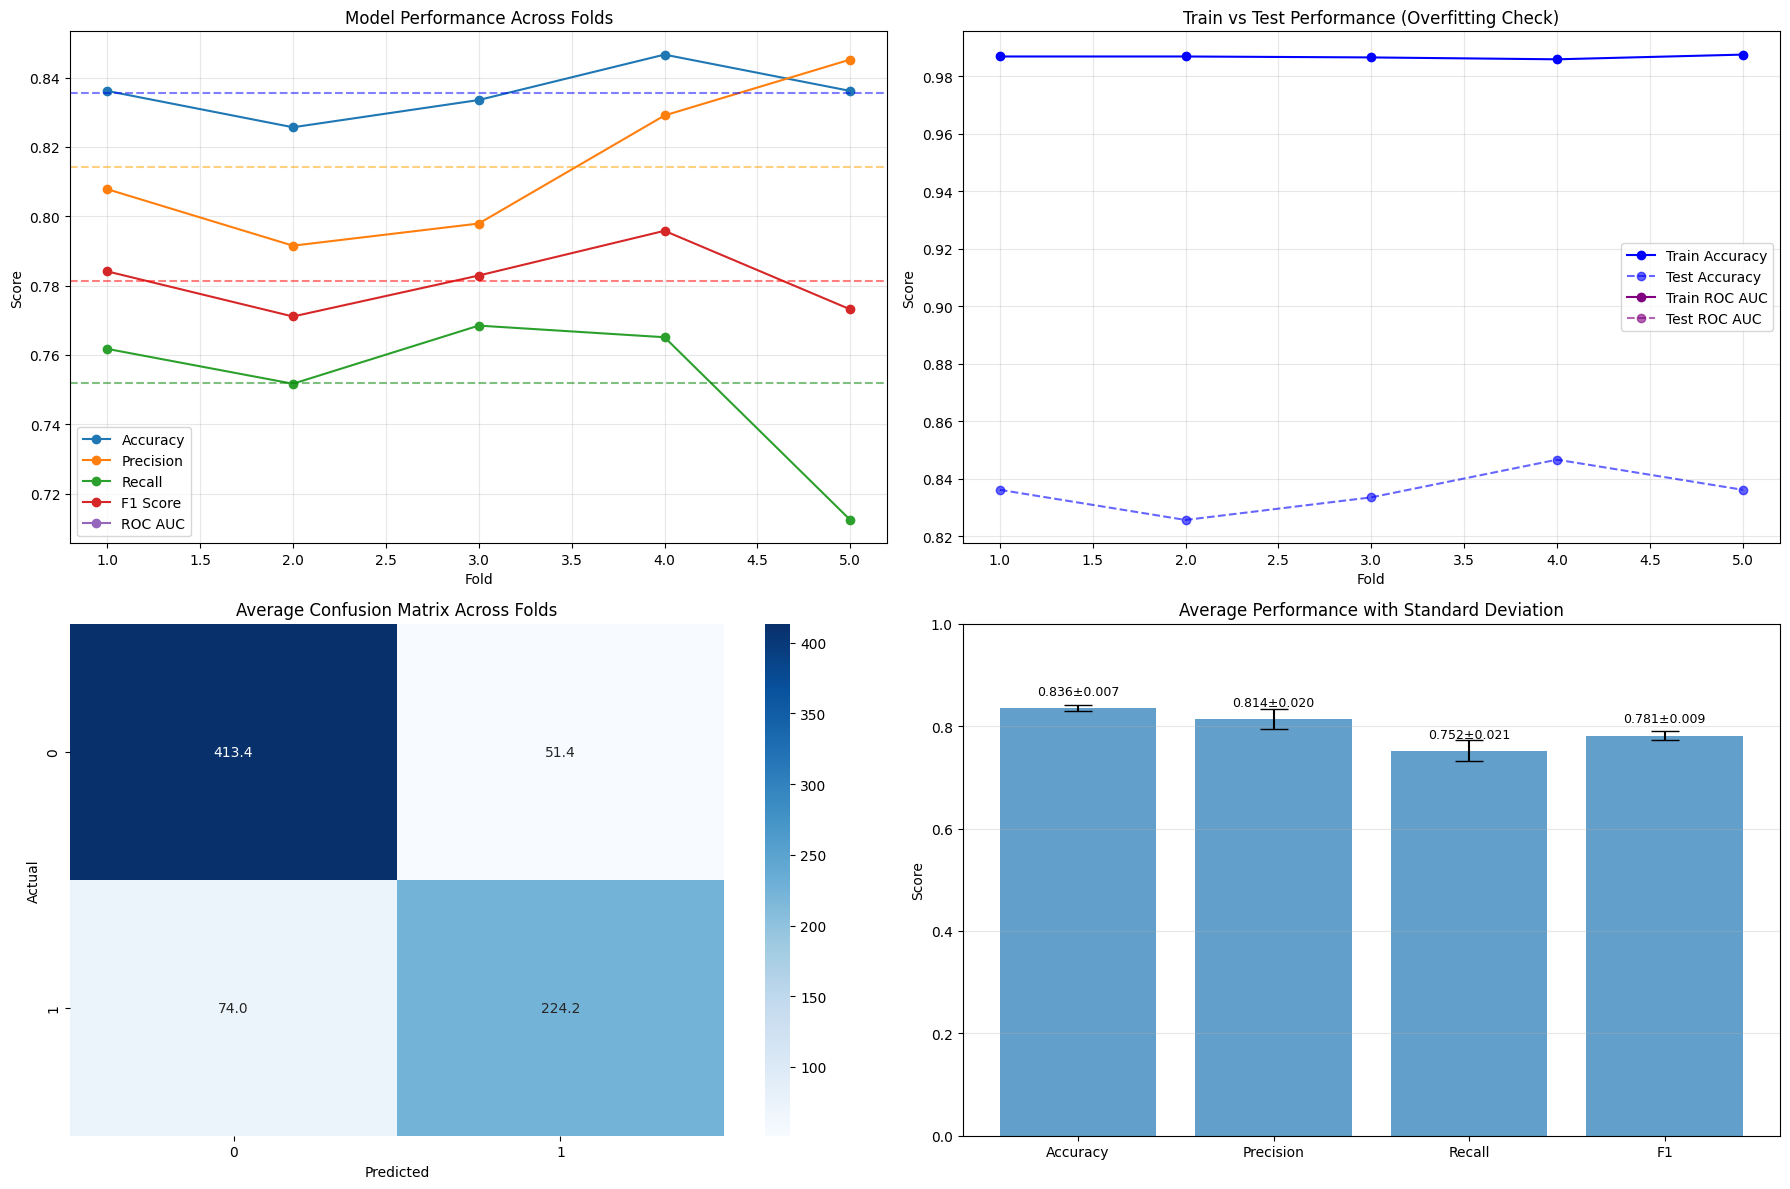

In [19]:
# Apply K-Fold Cross-Validation and optain results

k = 5
cv_results_morgan2 = perform_kfold_cv(
    fingerprint_to_model_morgan2,
    label_to_model,
    model_RF_morgan2,
    k=k,
    random_state=SEED,
)
cv_results_maccs = perform_kfold_cv(
    fingerprint_to_model_maccs,
    label_to_model,
    model_RF_maccs,
    k=k,
    random_state=SEED,
)

# Visualize the results
visualize_cv_results(cv_results_morgan2)


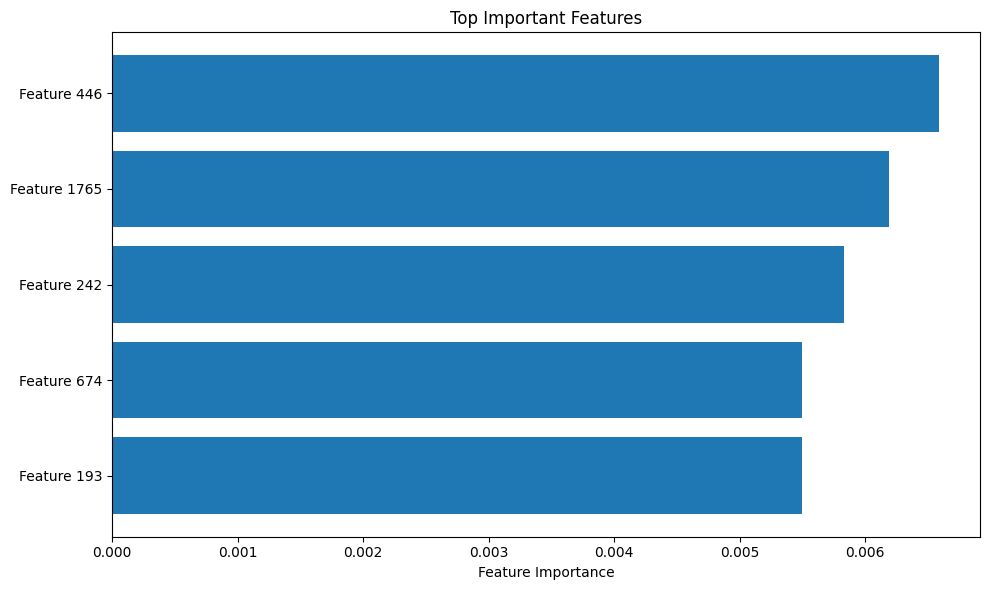

Top 5 Important Features:
        Feature  Importance
0   Feature 446    0.006584
1  Feature 1765    0.006191
2   Feature 242    0.005827
3   Feature 674    0.005499
4   Feature 193    0.005495


In [20]:
# Analyze the top features
analyze_feature_importance(cv_results_morgan2, top_n=5,plot=True)

In [21]:
# Now we write a function to represent the actual bits

from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors, AllChem
from collections import defaultdict
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

def visualize_bit_molecule_pairs(compound_df, top_bits, radius=2, n_examples=5):
    """
    Creates a grid visualization where each fingerprint bit is paired with 
    its complete source molecule.
    
    Parameters
    ----------
    compound_df : pandas DataFrame
        DataFrame containing 'smiles' and 'active' columns
    top_bits : list
        List of important bit positions to visualize
    radius : int
        Morgan fingerprint radius
    n_examples : int
        Number of example molecules to find for each bit
    """
    # Get active compounds
    active_compounds = compound_df[compound_df['active'] == 1]
    
    # Dictionary to store molecules that contain each bit
    bit_to_mols = defaultdict(list)
    
    print(f"Scanning {len(active_compounds)} active compounds for important fingerprint bits...")
    
    # Find molecules containing each target bit
    for idx, row in active_compounds.iterrows():
        smiles = row['smiles']
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            continue
            
        # Generate bit info for this molecule
        bit_info = {}
        fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=2048, bitInfo=bit_info)
        
        # Ensure the molecule has 2D coordinates
        if not mol.GetNumConformers():
            AllChem.Compute2DCoords(mol)
        
        # Check if any of our top bits are in this molecule
        for bit in top_bits:
            if bit in bit_info and len(bit_to_mols[bit]) < n_examples:
                # Store molecule with its ChEMBL ID if available
                mol_id = row.get('molecule_chembl_id', f"Compound_{idx}")
                bit_to_mols[bit].append((mol, mol_id, bit_info))
    
    # Process each bit
    for bit in top_bits:
        if not bit_to_mols[bit]:
            print(f"\nBit {bit}: No examples found in active compounds")
            continue
            
        print(f"\nBit {bit}: Found {len(bit_to_mols[bit])} example molecules")
        
        # Create a combined grid for this bit with pairs of fingerprint-molecule
        all_mols = []
        all_legends = []
        
        for mol, mol_id, bit_info in bit_to_mols[bit]:
            # Create the pair: fingerprint highlight and complete molecule
            # First the fingerprint bit highlight
            bit_tuple = (mol, bit, bit_info)
            # Draw the bit highlight as a separate image
            bit_img = Draw.DrawMorganBit(mol, bit, bit_info)
            # Convert the image to a PIL Image
            # Add to the grid with appropriate labels
            all_mols.append(bit_img)
            all_legends.append(f"{mol_id}: Bit {bit}")
            
            # Then the complete molecule
            all_mols.append(mol)
            all_legends.append(f"{mol_id}: Full Structure")
        
        # Use matplotlib to create a proper grid display
        fig = plt.figure(figsize=(12, 3*len(bit_to_mols[bit])))
        
        for i in range(len(all_mols)):
            ax = fig.add_subplot(len(bit_to_mols[bit]), 2, i+1)
            if isinstance(all_mols[i], Chem.Mol):
                img = Draw.MolToImage(all_mols[i], size=(300, 300))
                ax.imshow(img)
            else:
                ax.imshow(all_mols[i])
            ax.set_title(all_legends[i])
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Provide a chemical interpretation of this bit
        explain_bit_chemistry(bit_to_mols[bit], bit, radius)

    print(f"\nVisualization Guide:")
    print("• Blue atoms: Central atoms where the fingerprint is centered")
    print("• Yellow atoms: Aromatic atoms in the system")
    print("• Light gray: Atoms affecting the environment but not directly part of the fingerprint")
    print(f"• Environment radius: {radius} bonds from center")

def explain_bit_chemistry(examples, bit, radius):
    """
    Provides a chemical interpretation of what a fingerprint bit represents.
    
    Parameters
    ----------
    examples : list
        List of (molecule, mol_id, bit_info) tuples
    bit : int
        Bit position
    radius : int
        Morgan fingerprint radius
    """
    if not examples:
        return
    
    # Analyze chemical environments across examples
    center_atom_types = []
    neighbor_elements = set()
    ring_systems = []
    
    for mol, _, bit_info in examples:
        # Get central atoms for this bit
        for atom_id, _ in bit_info[bit]:
            atom = mol.GetAtomWithIdx(atom_id)
            center_atom_types.append(atom.GetSymbol())
            
            if atom.GetIsAromatic():
                is_aromatic = True
            
            # Check neighbors
            for neighbor in atom.GetNeighbors():
                neighbor_elements.add(neighbor.GetSymbol())
            
            # Check if part of a ring
            if atom.IsInRing():
                # Determine if it's in a 5 or 6-membered ring
                for ring_size in range(3, 8):
                    if atom.IsInRingSize(ring_size) and f"{ring_size}-membered ring" not in ring_systems:
                        ring_systems.append(f"{ring_size}-membered ring")

Scanning 1491 active compounds for important fingerprint bits...


[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerator
[08:24:54] DEPRECATION WARNING: please use MorganGenerat


Bit 446: Found 2 example molecules


[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator
[08:24:55] DEPRECATION WARNING: please use MorganGenerator


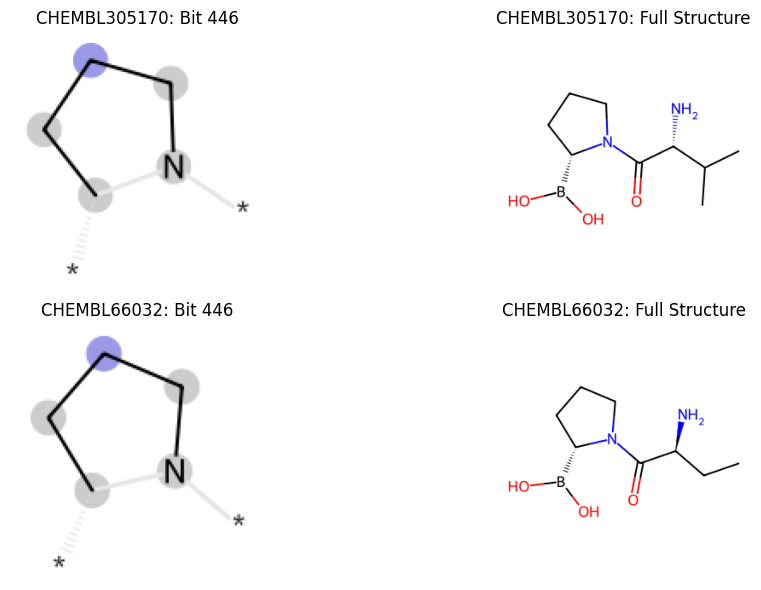


Bit 1765: Found 2 example molecules


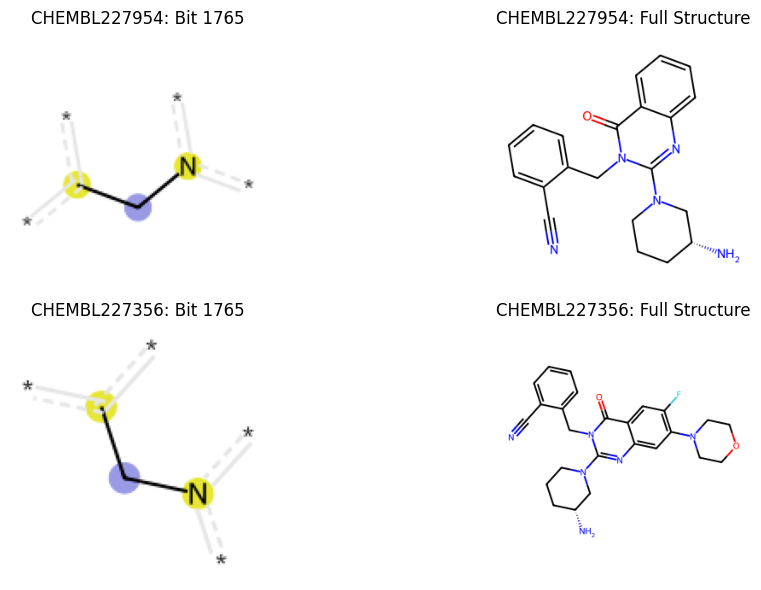


Visualization Guide:
• Blue atoms: Central atoms where the fingerprint is centered
• Yellow atoms: Aromatic atoms in the system
• Light gray: Atoms affecting the environment but not directly part of the fingerprint
• Environment radius: 2 bonds from center


In [22]:
# We now select top 3 bits for visualization
top_3_bits_morgan2 = [446,1765]
top_3_bits_maccs= [41,103]
# Visualize the bits and their corresponding molecules
visualize_bit_molecule_pairs(chembl_df, top_3_bits_morgan2, radius=2, n_examples=2)

ROC curve saved as roc_curve_morgan2.png


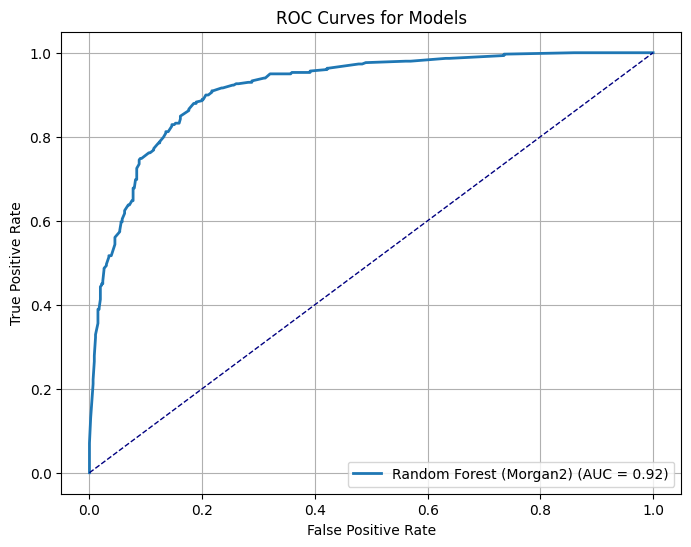

In [23]:
# Finally plot the ROC curves for the model
# fit model to training data
model_RF_morgan2.fit(static_train_x_morgan2, static_train_y_morgan2)
models = {
    "Random Forest (Morgan2)": model_RF_morgan2,
}

plot_roc_curves_for_models(models, static_test_x_morgan2, static_test_y_morgan2, save_png=True, filename="roc_curve_morgan2.png")

In [24]:
# correction Model make much better model with grid search

from sklearn.model_selection import GridSearchCV
import pandas as pd
import seaborn as sns

param_grid = {
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced','balanced_subsample', None]
}

model_RF_morgan2_grid = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=SEED
)

grid_search = GridSearchCV(
    estimator=model_RF_morgan2_grid,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search.fit(static_train_x_morgan2, static_train_y_morgan2)

# Get the best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation score: 0.9043


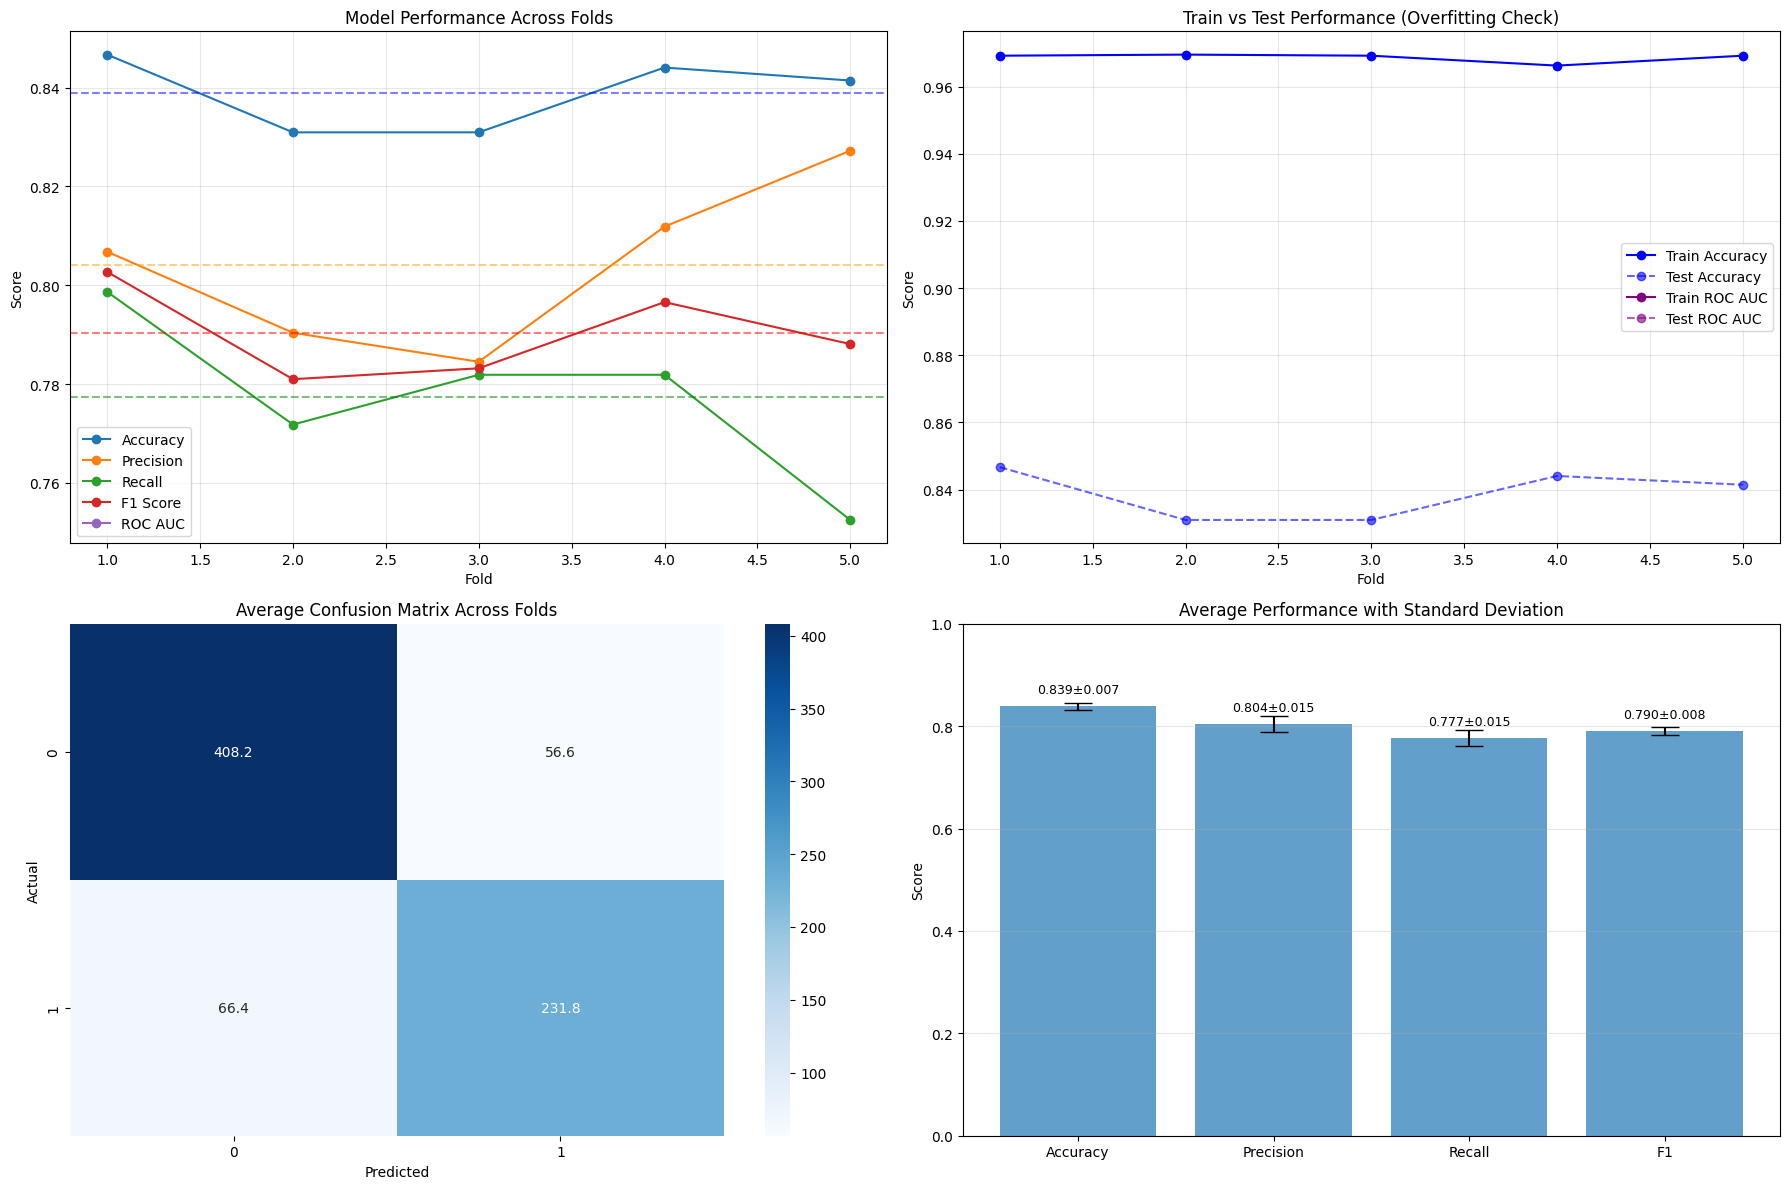

In [25]:
# make best_model with grid parameters and make k-fold validation
best_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=SEED,
    **best_params
)
# Perform k-fold cross-validation
cv_results_best = perform_kfold_cv(
    fingerprint_to_model_morgan2,
    label_to_model,
    best_model,
    k=k,
    random_state=SEED,
)
# Visualize the results
visualize_cv_results(cv_results_best)

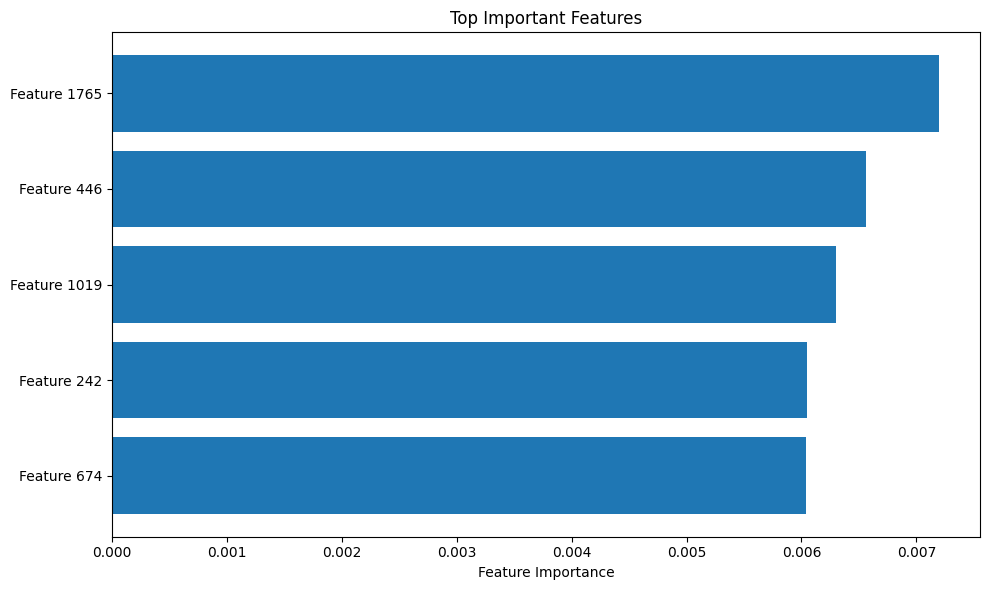

Top 5 Important Features:
        Feature  Importance
0  Feature 1765    0.007194
1   Feature 446    0.006563
2  Feature 1019    0.006301
3   Feature 242    0.006052
4   Feature 674    0.006036


In [26]:
analyze_feature_importance(cv_results_best, top_n=5,plot=True)



Scanning 1491 active compounds for important fingerprint bits...


[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerator
[09:13:12] DEPRECATION WARNING: please use MorganGenerat


Bit 1765: Found 2 example molecules


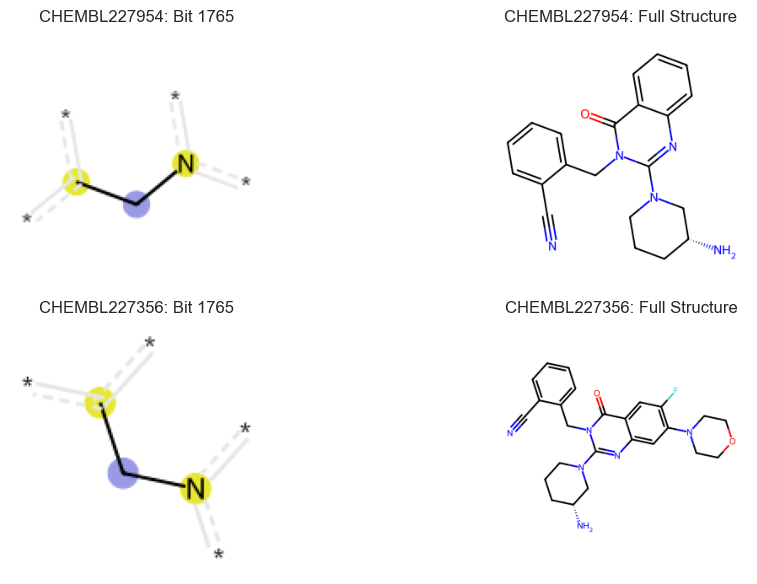


Bit 446: Found 2 example molecules


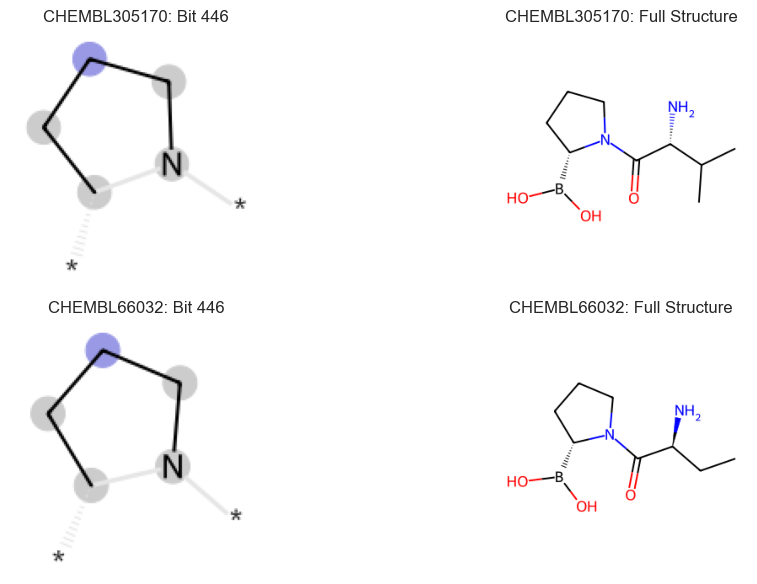


Visualization Guide:
• Blue atoms: Central atoms where the fingerprint is centered
• Yellow atoms: Aromatic atoms in the system
• Light gray: Atoms affecting the environment but not directly part of the fingerprint
• Environment radius: 2 bonds from center


In [36]:
top_5_features = [1765,446]

# Visualize the bits and their corresponding molecules
visualize_bit_molecule_pairs(chembl_df, top_5_features, radius=2, n_examples=2)

# Support Vector Machine

We now train a support vector machine with a radial basis function kernel.

In [27]:
from sklearn import svm

# Fit the SVM model
model_svm_morgan2 = svm.SVC(kernel="rbf",C=1.0,gamma=0.1,probability=True)



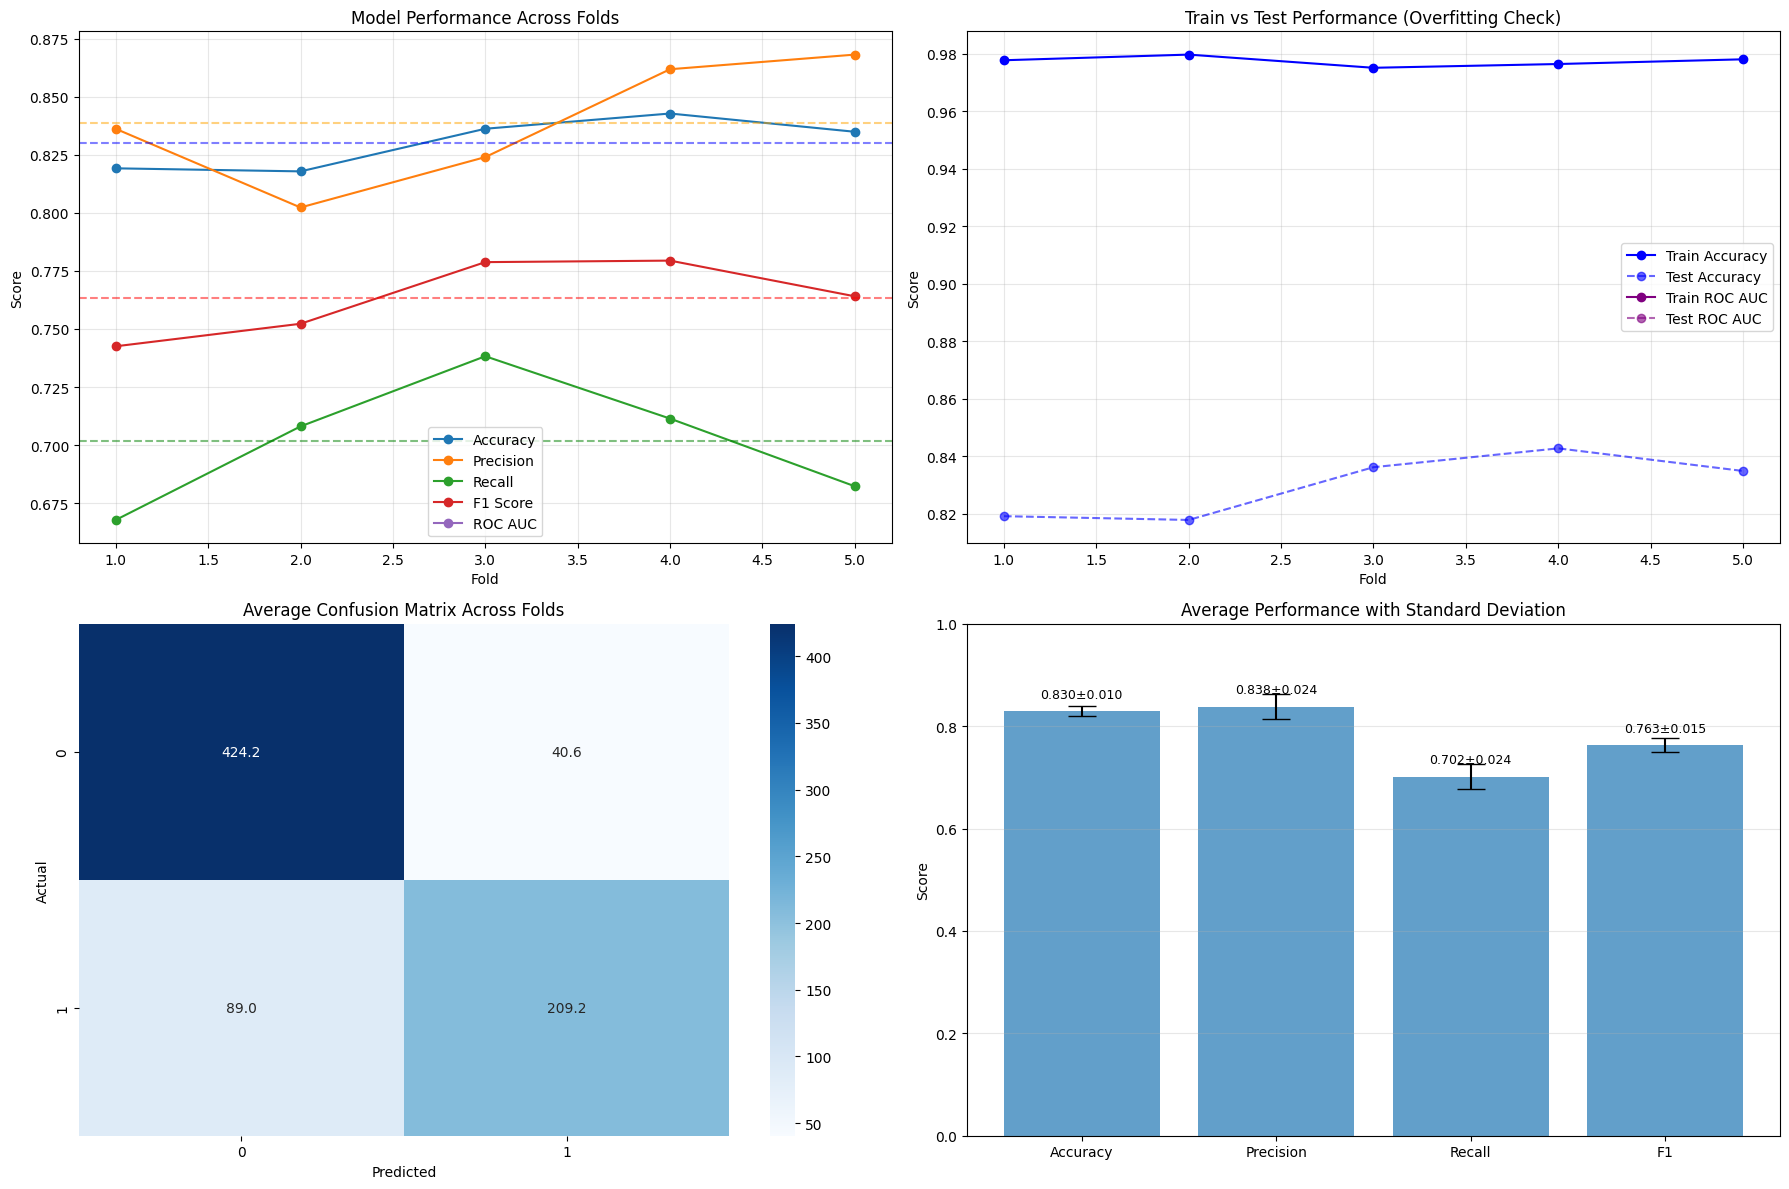

In [28]:
# Make K-Fold Cross-Validation
cv_results_svm_morgan2 = perform_kfold_cv(
    fingerprint_to_model_morgan2,
    label_to_model,
    model_svm_morgan2,
    k=k,
    random_state=SEED,
)

visualize_cv_results(cv_results_svm_morgan2)

In [29]:
#  Analyze the top features

analyze_feature_importance(cv_results_svm_morgan2, top_n=5,plot=True)

Feature importance not available in cross-validation results.


ROC curve saved as roc_curve_svm_morgan2.png


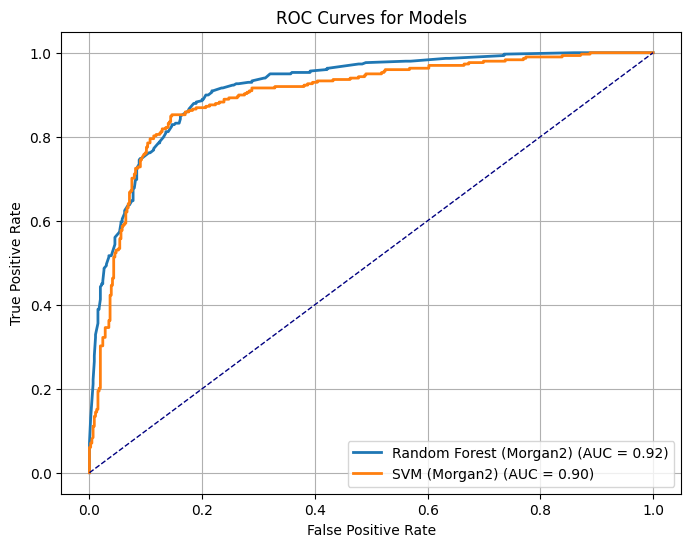

In [30]:
# Fit the model and plot both ROC curves
model_svm_morgan2.fit(static_train_x_morgan2, static_train_y_morgan2)
models = {
    "Random Forest (Morgan2)": model_RF_morgan2,
    "SVM (Morgan2)": model_svm_morgan2,
}
plot_roc_curves_for_models(models, static_test_x_morgan2, static_test_y_morgan2, save_png=True, filename="roc_curve_svm_morgan2.png")


In [37]:
# Set up hyperparameter tuning with GridsearchCV

from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    "C": [0.1,1,10,100],
    "gamma": [1,0.1,0.01,0.001],
    "kernel": ["linear", "rbf", "poly"],
}
grid_search_svm = GridSearchCV(
    estimator = model_svm_morgan2,
    param_grid = param_grid_svm,
    scoring = "roc_auc",
    cv = 5,
    n_jobs = -1,
    verbose = 1,
)

# Fit the model
grid_search_svm.fit(static_train_x_morgan2, static_train_y_morgan2)


best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_
print(f"Best parameters for SVM: {best_params_svm}")
print(f"Best cross-validation score for SVM: {best_score_svm:.4f}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for SVM: {'C': 10, 'gamma': 0.01, 'kernel': 'poly'}
Best cross-validation score for SVM: 0.8962


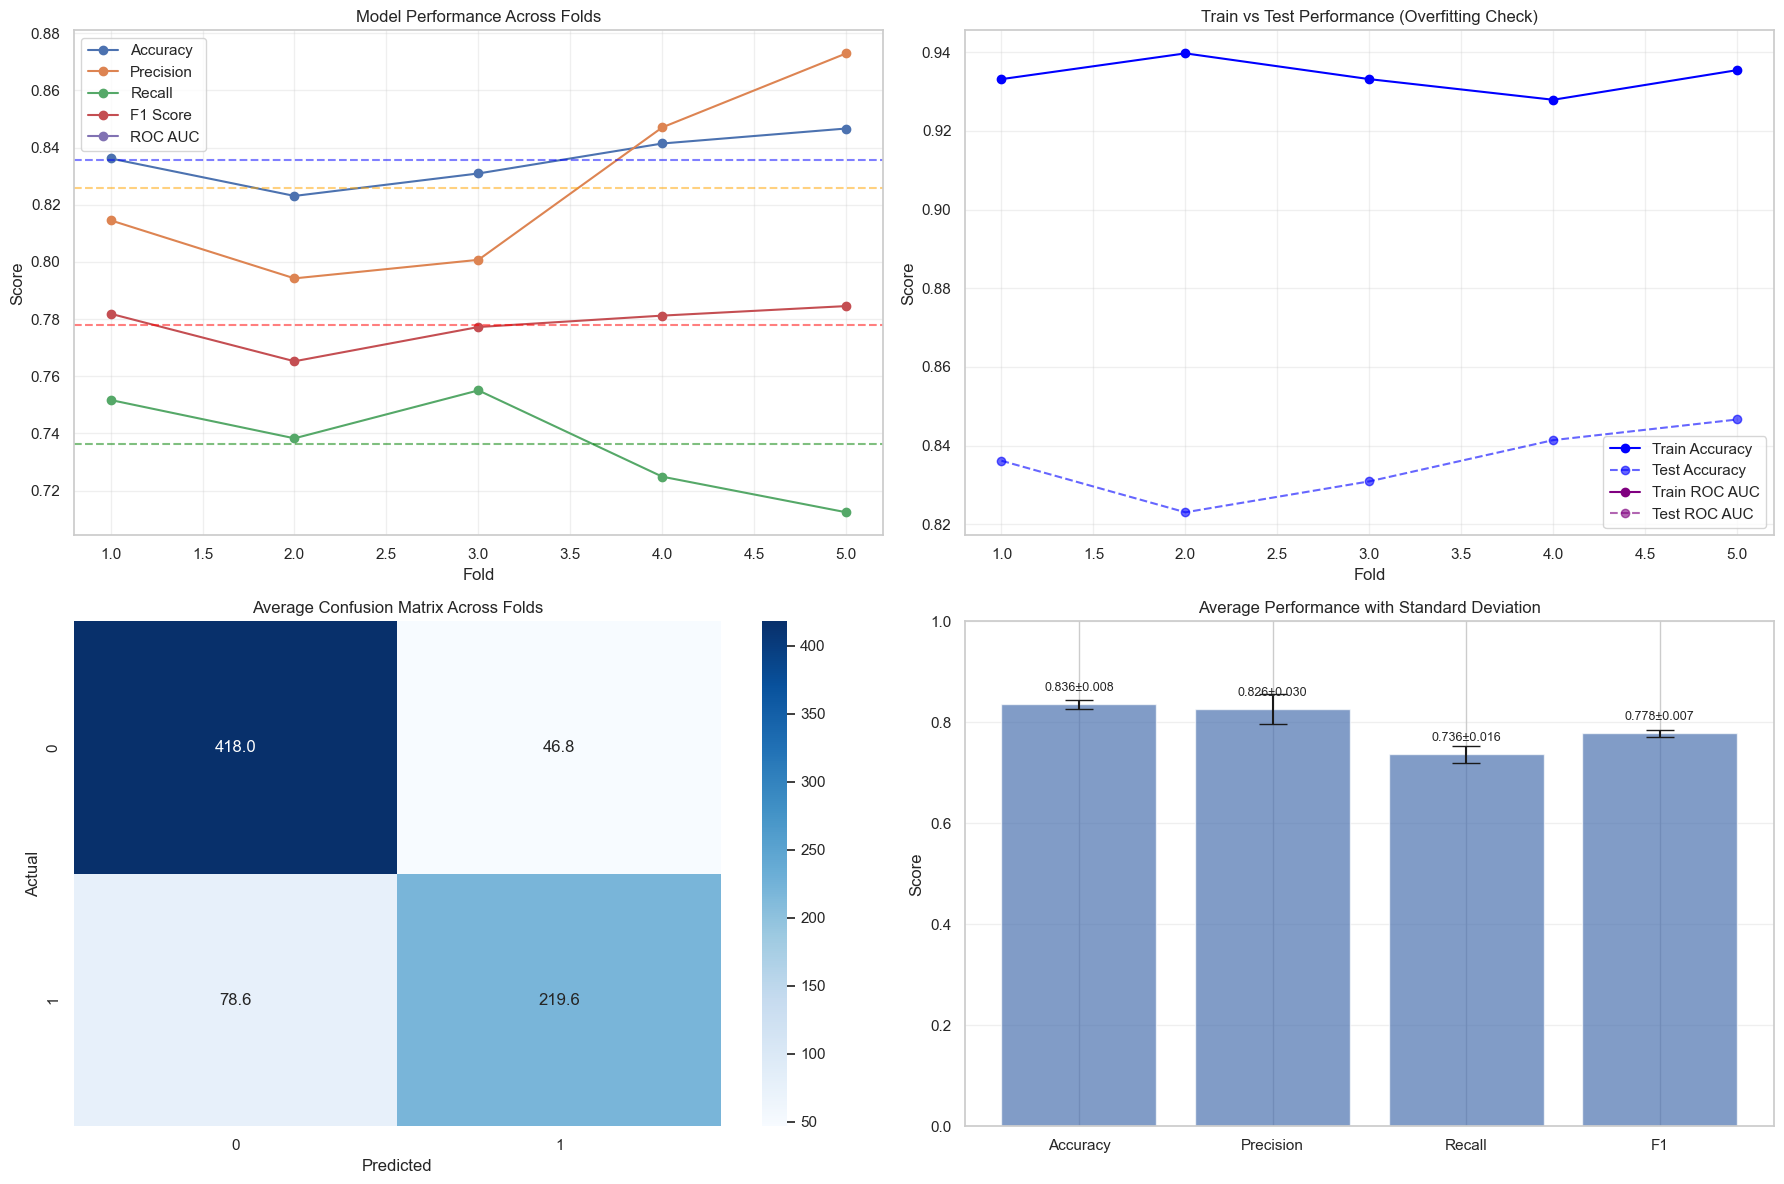

In [38]:
# Build Model with best parameters

best_model_svm = svm.SVC(
    kernel=best_params_svm["kernel"],
    C=best_params_svm["C"],
    gamma=best_params_svm["gamma"],
    probability=True,
)
# Perform k-fold cross-validation
cv_results_best_svm = perform_kfold_cv(
    fingerprint_to_model_morgan2,
    label_to_model,
    best_model_svm,
    k=k,
    random_state=SEED,
)
# Visualize the results
visualize_cv_results(cv_results_best_svm)  

# Neural Network Classifier

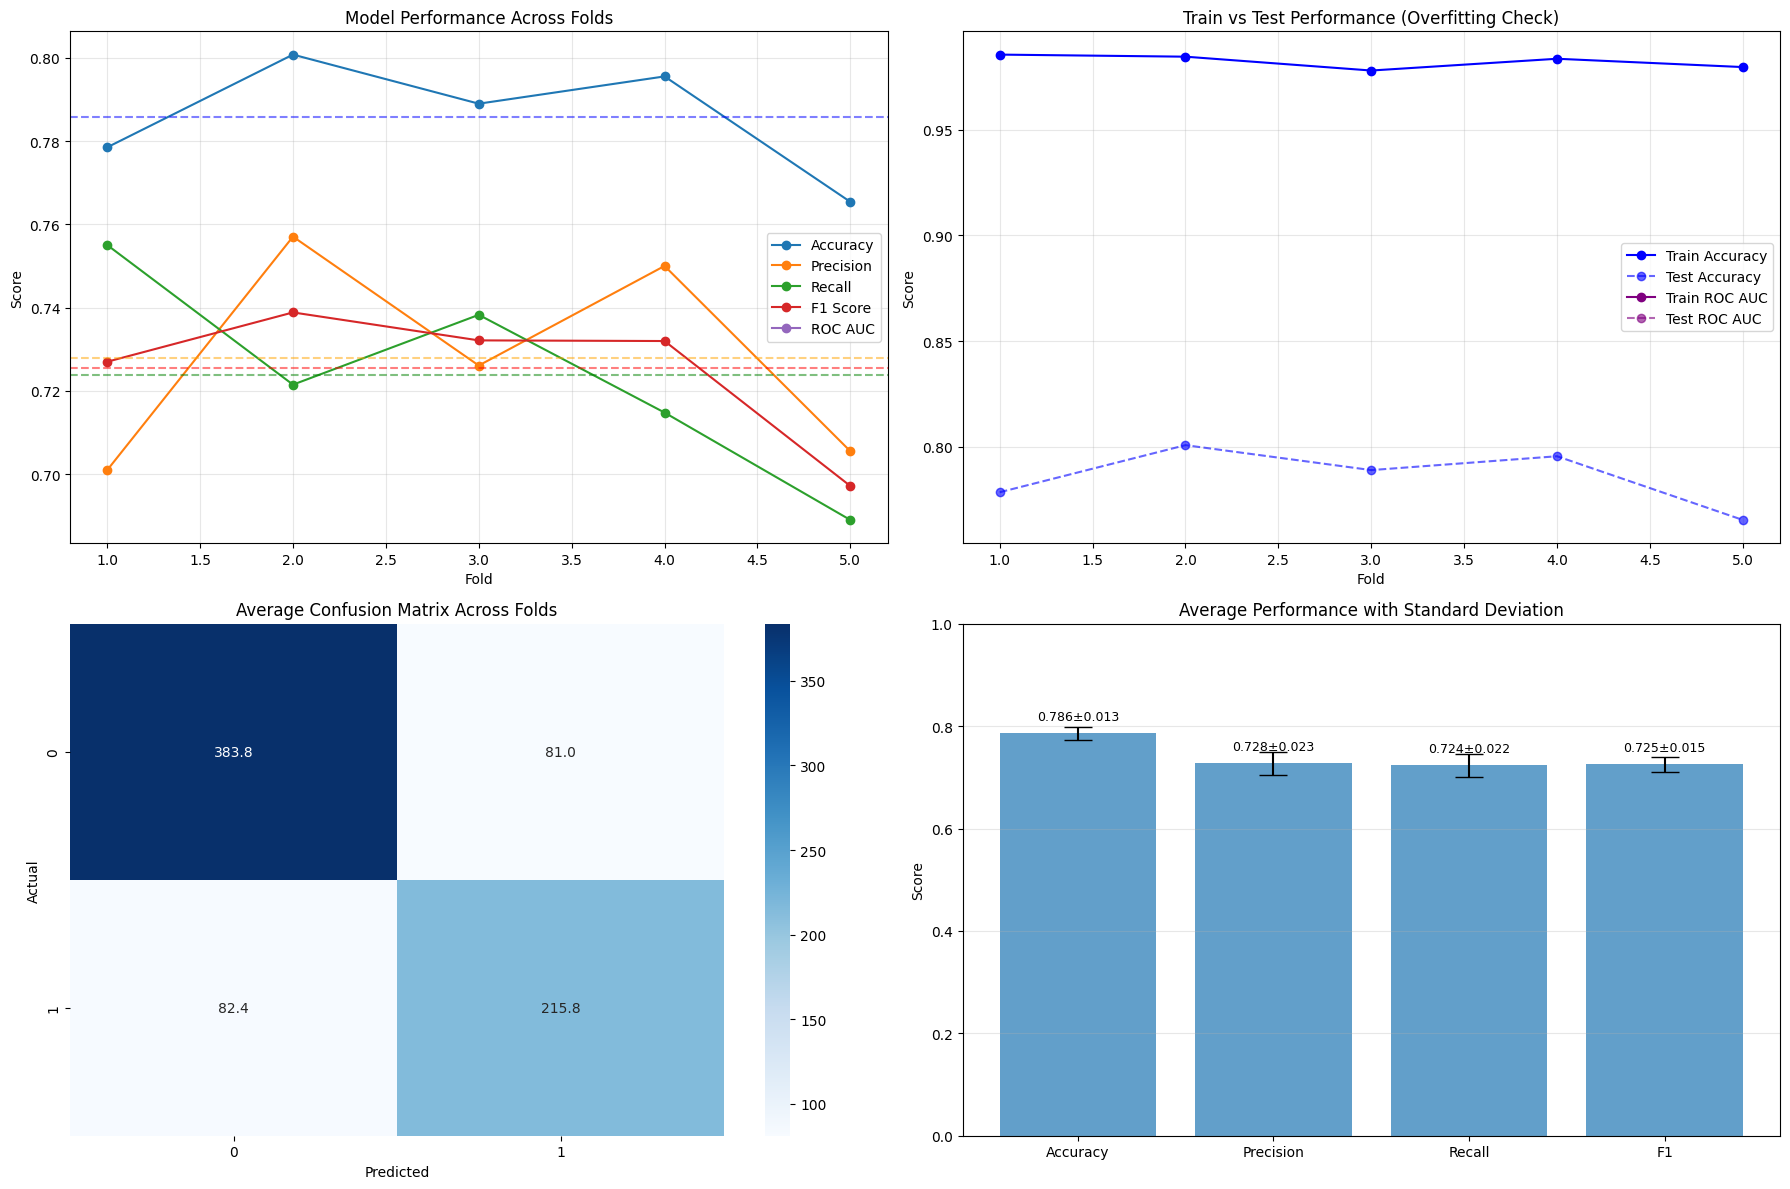

In [31]:
from sklearn.neural_network import MLPClassifier

model_ann_morgan2 = MLPClassifier(hidden_layer_sizes=(5,3),random_state=SEED)

model_ann_morgan2.fit(static_train_x_morgan2, static_train_y_morgan2)

# Make K-Fold Cross-Validation
cv_results_ann_morgan2 = perform_kfold_cv(
    fingerprint_to_model_morgan2,
    label_to_model,
    model_ann_morgan2,
    k=k,
    random_state=SEED,
)
visualize_cv_results(cv_results_ann_morgan2)

ROC curve saved as roc_curve_all_morgan2.png


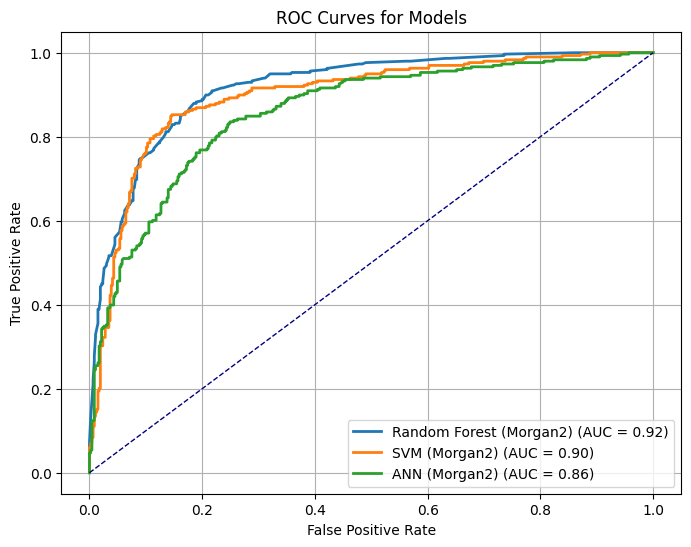

In [32]:
# plot all ROC curves
models = {
    "Random Forest (Morgan2)": model_RF_morgan2,
    "SVM (Morgan2)": model_svm_morgan2,
    "ANN (Morgan2)": model_ann_morgan2,
}
plot_roc_curves_for_models(models, static_test_x_morgan2, static_test_y_morgan2, save_png=True, filename="roc_curve_all_morgan2.png")

In [39]:
# Set up hyperparameter tuning with GridsearchCV

param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [200, 300, 400]
}


mlp = MLPClassifier(random_state=SEED)

grid_search_ann = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
# Fit the model
grid_search_ann.fit(static_train_x_morgan2, static_train_y_morgan2)

best_params_ann = grid_search_ann.best_params_
best_score_ann = grid_search_ann.best_score_
print(f"Best parameters for ANN: {best_params_ann}")
print(f"Best cross-validation score for ANN: {best_score_ann:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/home/lme/.conda/envs/mol_mod_pr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lme/.conda/envs/mol_mod_pr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lme/.conda/envs/mol_mod_pr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/lme/.conda/envs/mol_mod_pr/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.wa

Best parameters for ANN: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (150, 100, 50), 'learning_rate': 'constant', 'max_iter': 200, 'solver': 'sgd'}
Best cross-validation score for ANN: 0.8886


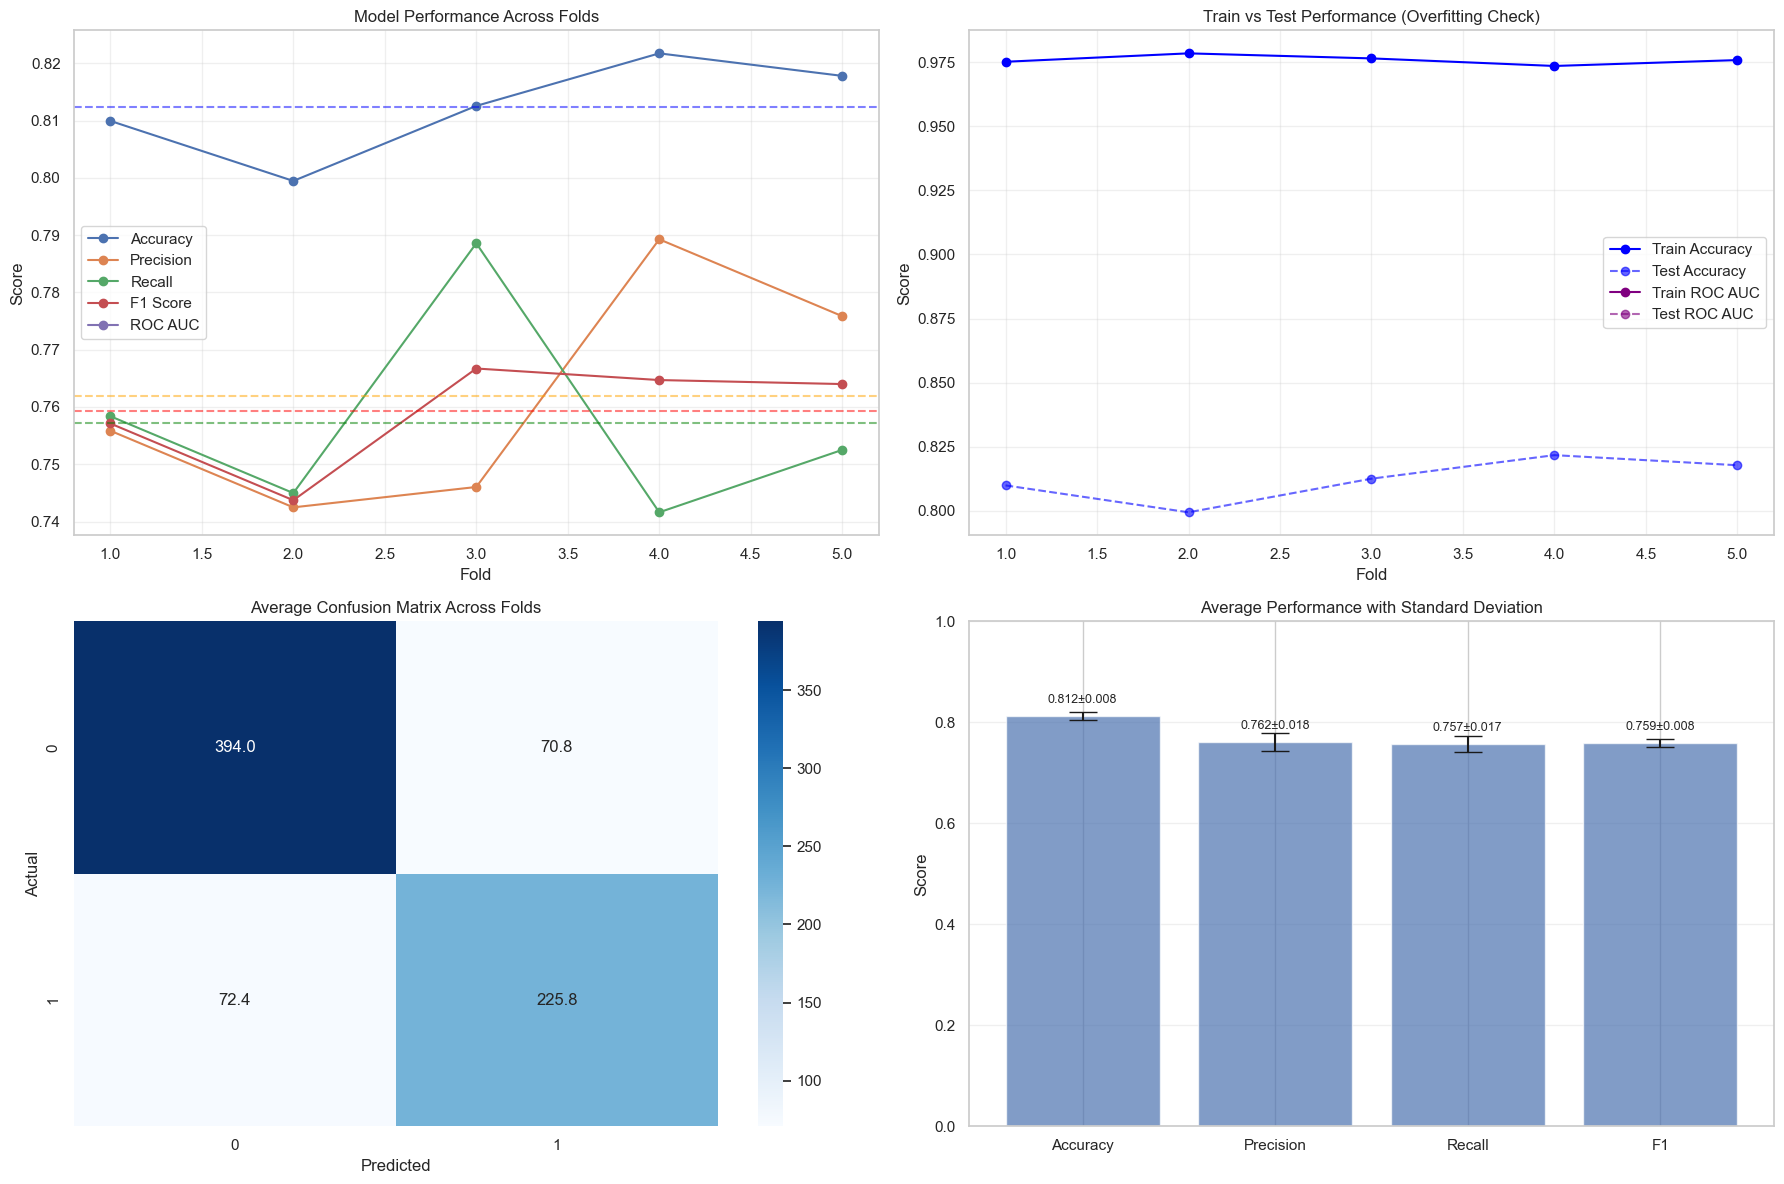

In [40]:
# Make best_model with grid parameters and make k-fold validation

best_model_ann = MLPClassifier(
    hidden_layer_sizes=best_params_ann['hidden_layer_sizes'],
    activation=best_params_ann['activation'],
    solver=best_params_ann['solver'],
    alpha=best_params_ann['alpha'],
    learning_rate=best_params_ann['learning_rate'],
    max_iter=best_params_ann['max_iter'],
    random_state=SEED
)
# Perform k-fold cross-validation
cv_results_best_ann = perform_kfold_cv(
    fingerprint_to_model_morgan2,
    label_to_model,
    best_model_ann,
    k=k,
    random_state=SEED,
)
# Visualize the results
visualize_cv_results(cv_results_best_ann)

ROC curve saved as roc_curve_all_gridsearch_morgan2.png


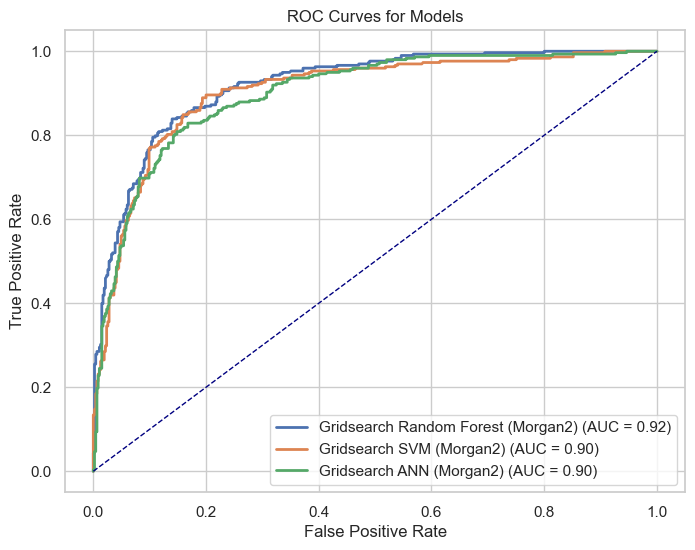

In [42]:
# Plot all the ROC Curves

# fit model to training data
best_model_ann.fit(static_train_x_morgan2, static_train_y_morgan2)
# fit model to training data
best_model.fit(static_train_x_morgan2, static_train_y_morgan2)
# fit model to training data
best_model_svm.fit(static_train_x_morgan2, static_train_y_morgan2)

models = {
    "Gridsearch Random Forest (Morgan2)": best_model,
    "Gridsearch SVM (Morgan2)": best_model_svm,
    "Gridsearch ANN (Morgan2)": best_model_ann,
}
plot_roc_curves_for_models(models, static_test_x_morgan2, static_test_y_morgan2, save_png=True, filename="roc_curve_all_gridsearch_morgan2.png")

# Predict Compounds obtained from Docking


In [45]:
ro5_violated = ["CHEMBL475655","CHEMBL460951","CHEMBL1203953","CHEMBL2203319","CHEMBL5276657"]
ro5_fulfilled = ["CHEMBL233684","CHEMBL237786","CHEMBL475654","CHEMBL391252","CHEMBL237569"]


# Get the indices of the rows that contain the specified IDs
indices = chembl_df[chembl_df['molecule_chembl_id'].isin(ro5_violated)].index
indices_fulfilled = chembl_df[chembl_df['molecule_chembl_id'].isin(ro5_fulfilled)].index

# Generate morgan2 fingerprints for the specified IDs
ro5_violated_fingerprints = chembl_df.loc[indices, "morgan2"].tolist()
ro5_fulfilled_fingerprints = chembl_df.loc[indices_fulfilled, "morgan2"].tolist()

# Predict Labels and probabilities for best model

ro5_violated_pred = best_model.predict(ro5_violated_fingerprints)
ro5_violated_prob = best_model.predict_proba(ro5_violated_fingerprints)[:, 1]
ro5_fulfilled_pred = best_model.predict(ro5_fulfilled_fingerprints)
ro5_fulfilled_prob = best_model.predict_proba(ro5_fulfilled_fingerprints)[:, 1]

# Then for svm  

ro5_violated_pred_svm = best_model_svm.predict(ro5_violated_fingerprints)
ro5_violated_prob_svm = best_model_svm.predict_proba(ro5_violated_fingerprints)[:, 1]
ro5_fulfilled_pred_svm = best_model_svm.predict(ro5_fulfilled_fingerprints)
ro5_fulfilled_prob_svm = best_model_svm.predict_proba(ro5_fulfilled_fingerprints)[:, 1]

# Then for ann
ro5_violated_pred_ann = best_model_ann.predict(ro5_violated_fingerprints)
ro5_violated_prob_ann = best_model_ann.predict_proba(ro5_violated_fingerprints)[:, 1]
ro5_fulfilled_pred_ann = best_model_ann.predict(ro5_fulfilled_fingerprints)
ro5_fulfilled_prob_ann = best_model_ann.predict_proba(ro5_fulfilled_fingerprints)[:, 1]

# Print the results
print("RO5 Violated Compounds Predictions:")
for i, (pred, prob) in enumerate(zip(ro5_violated_pred, ro5_violated_prob)):
    print(f"ID: {ro5_violated[i]}, Prediction: {pred}, Probability: {prob:.4f}")
print("\nRO5 Fulfilled Compounds Predictions:")
for i, (pred, prob) in enumerate(zip(ro5_fulfilled_pred, ro5_fulfilled_prob)):
    print(f"ID: {ro5_fulfilled[i]}, Prediction: {pred}, Probability: {prob:.4f}")



RO5 Violated Compounds Predictions:
ID: CHEMBL475655, Prediction: 0, Probability: 0.4552
ID: CHEMBL460951, Prediction: 0, Probability: 0.0000
ID: CHEMBL1203953, Prediction: 0, Probability: 0.0350
ID: CHEMBL2203319, Prediction: 1, Probability: 0.6161
ID: CHEMBL5276657, Prediction: 1, Probability: 0.9629

RO5 Fulfilled Compounds Predictions:
ID: CHEMBL233684, Prediction: 0, Probability: 0.1050
ID: CHEMBL237786, Prediction: 0, Probability: 0.3066
ID: CHEMBL475654, Prediction: 0, Probability: 0.3266
ID: CHEMBL391252, Prediction: 0, Probability: 0.2139
ID: CHEMBL237569, Prediction: 0, Probability: 0.0082


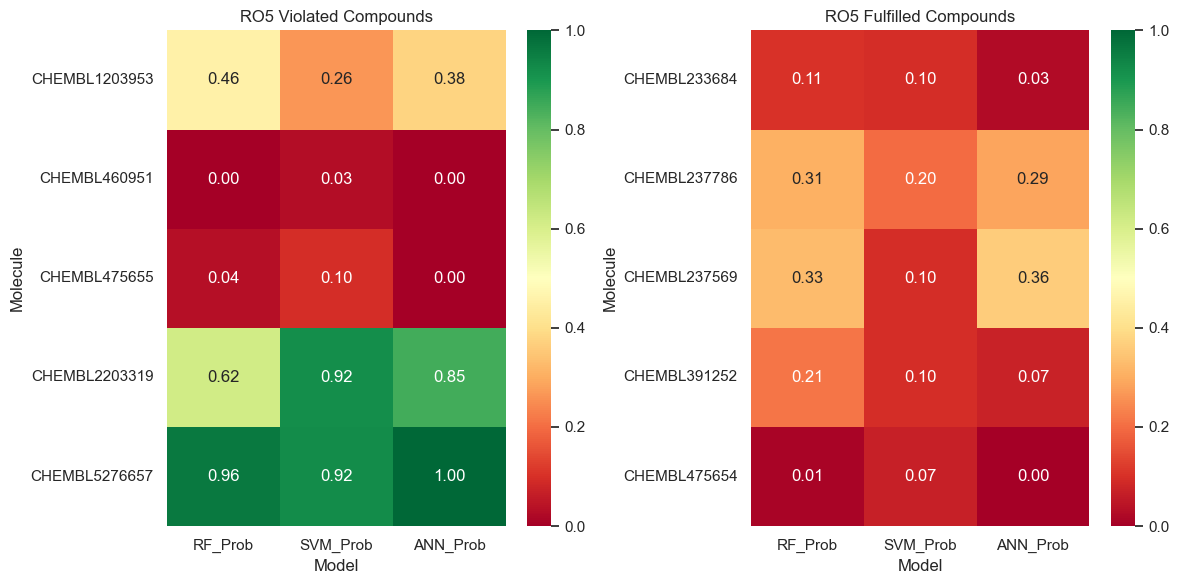

In [48]:
# Create DataFrames for violated and fulfilled compounds

df_violated = pd.DataFrame({
    "Molecule": chembl_df.loc[indices, "molecule_chembl_id"],
    "RF_Prob": ro5_violated_prob,
    "SVM_Prob": ro5_violated_prob_svm,
    "ANN_Prob": ro5_violated_prob_ann,
    "RF_Pred": ro5_violated_pred,
    "SVM_Pred": ro5_violated_pred_svm,
    "ANN_Pred": ro5_violated_pred_ann
})

df_fulfilled = pd.DataFrame({
    "Molecule": chembl_df.loc[indices_fulfilled, "molecule_chembl_id"],
    "RF_Prob": ro5_fulfilled_prob,
    "SVM_Prob": ro5_fulfilled_prob_svm,
    "ANN_Prob": ro5_fulfilled_prob_ann,
    "RF_Pred": ro5_fulfilled_pred,
    "SVM_Pred": ro5_fulfilled_pred_svm,
    "ANN_Pred": ro5_fulfilled_pred_ann
})

# Plot two heatmaps for violated and fulfilled in two subplots

# scale that there is one unified color scale
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set cmap where 1 is active gren and 0 is red

cmap = sns.color_palette("RdYlGn", as_cmap=True)

vmin  = 0

vmax = 1


sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Plot for RO5 violated compounds compounds on y axis with chembl id
sns.heatmap(df_violated[["RF_Prob", "SVM_Prob", "ANN_Prob"]], 
            annot=True, 
            fmt=".2f", 
            cmap=cmap, 
            ax=axes[0],
            yticklabels=df_violated["Molecule"],
            vmin=vmin,
            vmax=vmax)
axes[0].set_title("RO5 Violated Compounds")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Molecule")

# Plot for RO5 fulfilled compounds
sns.heatmap(df_fulfilled[["RF_Prob", "SVM_Prob", "ANN_Prob"]],
             annot=True, 
             fmt=".2f", 
             cmap=cmap,
             ax=axes[1],
             yticklabels=df_fulfilled["Molecule"],
             vmin=vmin,
             vmax=vmax)

# Rotate y tick labels for better visibility

axes[1].set_title("RO5 Fulfilled Compounds")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Molecule")
plt.tight_layout()
plt.savefig("ro5_violated_fulfilled_heatmap_ml.png", dpi=300)
plt.show()

In [35]:
# Pivot data for heatmap
heatmap_data = df.pivot_table(
    index="Molecule",
    columns="Model",
    values="Probability",
    aggfunc="mean"
)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Probability"}
)
plt.title("Predicted Probabilities (Heatmap)")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined